In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# standard imports
import tensorrt #For GPU
from tensorflow import keras
import numpy as np
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras import layers
import random
from sklearn import preprocessing
from keras.callbacks import History
import matplotlib.pyplot as plt
import np_utils
import os
from tensorflow.keras.optimizers import Adam
from plain_neural_network import*
from keras import backend as K

%matplotlib inline

2024-05-23 18:45:13.011038: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6607949638391450534
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 45610434560
locality {
  bus_id: 2
  numa_node: 1
  links {
  }
}
incarnation: 3906084927112824497
physical_device_desc: "device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6"
xla_global_id: 416903419
]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2024-05-23 18:45:16.832278: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /device:GPU:0 with 43497 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6


In [3]:
import glob
input_dir = "/albedo/work/user/ssunar/for_paper/segmentation_masks/Gulfstream/"
input_file_paths = sorted(glob.glob(input_dir+'*.nc'))
# The first file throws an error when we do xr.open_mfdataset
data = xr.open_mfdataset(input_file_paths,combine = 'nested', concat_dim="TIME").astype('float32')
X = data.ssh.to_numpy()
Y = data.seg_mask.to_numpy()
X[X>1000] = 0

X.shape
Y.shape

(3958, 600, 300)

(3958, 600, 300)

In [4]:
data

<xarray.Dataset>
Dimensions:    (TIME: 3958, LONGITUDE: 600, LATITUDE: 300)
Coordinates:
  * LONGITUDE  (LONGITUDE) float32 -60.0 -59.92 -59.83 ... -10.25 -10.17 -10.08
  * LATITUDE   (LATITUDE) float32 30.0 30.08 30.17 30.25 ... 54.75 54.83 54.92
  * TIME       (TIME) float32 5.186e+05 5.187e+05 ... 6.136e+05 6.136e+05
Data variables:
    ssh        (TIME, LONGITUDE, LATITUDE) float32 dask.array<chunksize=(31, 600, 300), meta=np.ndarray>
    seg_mask   (TIME, LONGITUDE, LATITUDE) float32 dask.array<chunksize=(31, 600, 300), meta=np.ndarray>

In [5]:
data_long = data.LONGITUDE
data_lat = data.LATITUDE
xx, yy = np.meshgrid(data_long, data_lat)

/tmp/ipykernel_1979827/3071145902.py:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(data_long,data_lat,np.transpose(X[100,:,:]), cmap=cm.seismic, vmin=-1, vmax=1)


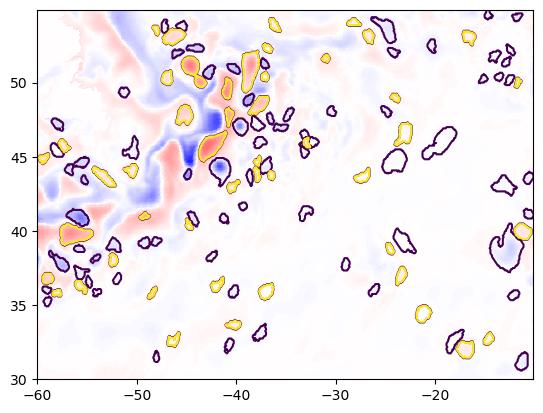

In [6]:
from matplotlib import cm
fig, ax = plt.subplots( 1, 1, )
ax.pcolormesh(data_long,data_lat,np.transpose(X[100,:,:]), cmap=cm.seismic, vmin=-1, vmax=1)
ax.contour(xx, yy, np.transpose(Y[100,:,:]), levels=[0,1])

In [7]:
Y[(Y != 1) & (Y!=2)] = 0

In [8]:
def split_3d_vector(vector):
    X, Y, Z = vector.shape
    chunks = []
    
    for i in range(X):
        vector_2d = vector[i,:,:]
        B = Y // 256 + 1
        for b in range(B):
            start_y = b * 256
            end_y = (b + 1) * 256
            if end_y > Y:
                start_y = Y - 256
                end_y = Y
      
            C = Z // 256 + 1
            for c in range(C):
                start_z = c * 256
                end_z = (c + 1) * 256
                if end_z > Z:
                    start_z = Z - 256
                    end_z = Z
                final_chunk = vector_2d[start_y:end_y, start_z:end_z]
                chunks.append(final_chunk)
    return chunks

In [9]:
new_X = np.array(split_3d_vector(X))
new_Y = np.array(split_3d_vector(Y))

data_x = new_X
data_y = new_Y

(data_x.shape)
(data_y.shape)

(23748, 256, 256)

(23748, 256, 256)

In [10]:
img_size = (256, 256)
num_classes = 3
batch_size = 32
epochs = 60
total_samples = len(data_x)-1000
# if len(data_x) > 4000:
#     total_samples = 4000
# else:
#     total_samples = len(data_x)
print(total_samples)

22748


In [11]:
def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (1,))
    #filters = 16
    
    for_concat = []
    p = inputs
    for index, dropout_filter in zip(range(1,6,1),[(0.2,32),(0.3,32),(0.4,64),(0.4,64),(0.5,128)]): 
        x = layers.SeparableConv2D(dropout_filter[1], 3, padding="same", use_bias=False)(p)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.SeparableConv2D(dropout_filter[1], 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = Dropout(dropout_filter[0])(x)
        for_concat.append(x)
        if index<5:
            p = layers.MaxPooling2D(pool_size=(2, 2))(x)
        elif index==5:
            p = x

    for index, dropout_filter in zip(range(4,0,-1),[(0.4,64),(0.4,64),(0.3,32),(0.2,32)]):
        x = concatenate([UpSampling2D((2,2))(p), for_concat[index-1]])
        x = SeparableConv2D(dropout_filter[1], 3, padding="same", use_bias=False)(x) 
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

        x = SeparableConv2D(dropout_filter[1], 3, padding="same", use_bias=False)(x) 
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout_filter[0])(x)
        p = x

    # Add a per-pixel classification layer
    
    X = SeparableConv2D(num_classes, (1,1), padding="same", use_bias=False)(x)   
    X = Reshape((img_size[0] * img_size[1], num_classes))(X) 
    outputs = Activation("softmax")(X)

    # Define the model
    model = keras.Model(inputs, outputs)
    return model

In [12]:
model = get_model(img_size, num_classes)
model.summary()

2024-05-23 18:45:54.076446: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43497 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 separable_conv2d (Separabl  (None, 256, 256, 32)         41        ['input_1[0][0]']             
 eConv2D)                                                                                         
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 32)         128       ['separable_conv2d[0][0]']    
 Normalization)                                                                                   
                                                                                              

 bleConv2D)                                                                                       
                                                                                                  
 batch_normalization_7 (Bat  (None, 32, 32, 64)           256       ['separable_conv2d_7[0][0]']  
 chNormalization)                                                                                 
                                                                                                  
 activation_7 (Activation)   (None, 32, 32, 64)           0         ['batch_normalization_7[0][0]'
                                                                    ]                             
                                                                                                  
 dropout_3 (Dropout)         (None, 32, 32, 64)           0         ['activation_7[0][0]']        
                                                                                                  
 max_pooli

 dropout_6 (Dropout)         (None, 64, 64, 64)           0         ['activation_13[0][0]']       
                                                                                                  
 up_sampling2d_2 (UpSamplin  (None, 128, 128, 64)         0         ['dropout_6[0][0]']           
 g2D)                                                                                             
                                                                                                  
 concatenate_2 (Concatenate  (None, 128, 128, 96)         0         ['up_sampling2d_2[0][0]',     
 )                                                                   'dropout_1[0][0]']           
                                                                                                  
 separable_conv2d_14 (Separ  (None, 128, 128, 32)         3936      ['concatenate_2[0][0]']       
 ableConv2D)                                                                                      
          

In [13]:
#Loss function 
#defined from the paper:
#Santana et al._2020_Neural network training for the detection and classification of oceanic mesoscale eddies

# unique, counts = np.unique(data_y, return_counts=True)
# dict(zip(unique, counts))

# freq = [np.sum(counts)/j for j in counts]
# weightsSeg = [f/np.sum(freq) for f in freq]
weightsSeg = [0.04, 0.48, 0.48]
print(weightsSeg)

def dice_coef_anti(y_true, y_pred):
    smooth = 1.  # to avoid zero division
    y_true_anti = y_true[:,:,1]
    y_pred_anti = y_pred[:,:,1]
    intersection_anti = K.sum(y_true_anti * y_pred_anti)
    return (2 * intersection_anti + smooth) / (K.sum(y_true_anti)+ K.sum(y_pred_anti) + smooth)

def dice_coef_cyc(y_true, y_pred):
    smooth = 1.  # to avoid zero division
    y_true_cyc = y_true[:,:,2]
    y_pred_cyc = y_pred[:,:,2]
    intersection_cyc = K.sum(y_true_cyc * y_pred_cyc)
    return (2 * intersection_cyc + smooth) / (K.sum(y_true_cyc) + K.sum(y_pred_cyc) + smooth)

def dice_coef_nn(y_true, y_pred):
    smooth = 1.  # to avoid zero division
    y_true_nn = y_true[:,:,0]
    y_pred_nn = y_pred[:,:,0]
    intersection_nn = K.sum(y_true_nn * y_pred_nn)
    return (2 * intersection_nn + smooth) / (K.sum(y_true_nn) + K.sum(y_pred_nn) + smooth)
    
def mean_dice_coef(y_true, y_pred):
    return (dice_coef_anti(y_true, y_pred) + dice_coef_cyc(y_true, y_pred) + dice_coef_nn(y_true, y_pred))/3.

def weighted_mean_dice_coef(y_true, y_pred):
    #return (weightsSeg[2]*dice_coef_anti(y_true, y_pred) + weightsSeg[1]*dice_coef_cyc(y_true, y_pred) + weightsSeg[0]*dice_coef_nn(y_true, y_pred))
    return (weightsSeg[2]*dice_coef_anti(y_true, y_pred) + weightsSeg[1]*dice_coef_cyc(y_true, y_pred) + weightsSeg[0]*dice_coef_nn(y_true, y_pred))
      
def dice_coef_loss(y_true, y_pred):
    return 1 - weighted_mean_dice_coef(y_true, y_pred)

[0.04, 0.48, 0.48]


In [14]:
# Split our img paths into a training and a validation set
split = 0.3
train_samples = int((1-split)*total_samples)
#same seed must be used
random.Random(0).shuffle(data_x)
random.Random(0).shuffle(data_y)
train_input = data_x[0:train_samples]
train_target = data_y[0:train_samples]
val_input = data_x[train_samples:total_samples]
val_target = data_y[train_samples:total_samples]

print("train_input:", train_input.shape)
print("val_input:", val_input.shape)

# Instantiate data Sequences for each split
train_gen = plain_net_eddy(batch_size, img_size, train_input, train_target)
val_gen = plain_net_eddy(batch_size, img_size, val_input, val_target)
print("Size of each batch: ",train_gen[1][0].shape)

train_input: (15923, 256, 256)
val_input: (6825, 256, 256)
Size of each batch:  (32, 256, 256, 1)


In [15]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/albedo/soft/sw/spack-sw/cuda/11.7.0-qk7q7bh/'
os.environ['XLA_FLAGS']
# print(os.environ.get('CUDA_HOME')) 

'--xla_gpu_cuda_data_dir=/albedo/soft/sw/spack-sw/cuda/11.7.0-qk7q7bh/'

In [16]:
file_path_save = "/albedo/work/user/ssunar/for_paper/unet_trained/Gulfstream_new"
os.makedirs(file_path_save, exist_ok=True)
model.compile(optimizer=Adam(lr=1e-3), loss=dice_coef_loss, metrics=['categorical_accuracy', mean_dice_coef, weighted_mean_dice_coef])

callbacks = [keras.callbacks.ModelCheckpoint(file_path_save, save_best_only=True , monitor='val_loss',save_weights_only=True, save_freq="epoch"),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1, mode='auto', min_delta=1e-30, min_lr=1e-30)]

# Train the model, doing validation at the end of each epoch.
history = model.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=callbacks, shuffle=True,verbose=1)

Epoch 1/60


2024-05-23 18:46:00.335492: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-05-23 18:46:02.305344: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8904
2024-05-23 18:46:03.687880: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2024-05-23 18:46:03.949283: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x15420990aad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-23 18:46:03.949309: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
2024-05-23 18:46:03.953766: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disablin

497/497 [==============================] - 163s 303ms/step - loss: 0.5304 - categorical_accuracy: 0.7975 - mean_dice_coef: 0.5785 - weighted_mean_dice_coef: 0.4696 - val_loss: 0.9094 - val_categorical_accuracy: 0.8472 - val_mean_dice_coef: 0.3430 - val_weighted_mean_dice_coef: 0.0906 - lr: 0.0010
Epoch 2/60
497/497 [==============================] - 151s 304ms/step - loss: 0.3680 - categorical_accuracy: 0.9030 - mean_dice_coef: 0.7270 - weighted_mean_dice_coef: 0.6320 - val_loss: 0.3842 - val_categorical_accuracy: 0.8890 - val_mean_dice_coef: 0.7134 - val_weighted_mean_dice_coef: 0.6158 - lr: 0.0010
Epoch 3/60
497/497 [==============================] - 151s 304ms/step - loss: 0.3449 - categorical_accuracy: 0.9089 - mean_dice_coef: 0.7441 - weighted_mean_dice_coef: 0.6551 - val_loss: 0.3386 - val_categorical_accuracy: 0.8915 - val_mean_dice_coef: 0.7451 - val_weighted_mean_dice_coef: 0.6614 - lr: 0.0010
Epoch 4/60
497/497 [==============================] - 151s 303ms/step - loss: 0.3317

497/497 [==============================] - 150s 303ms/step - loss: 0.2735 - categorical_accuracy: 0.9280 - mean_dice_coef: 0.7973 - weighted_mean_dice_coef: 0.7265 - val_loss: 0.2852 - val_categorical_accuracy: 0.9029 - val_mean_dice_coef: 0.7841 - val_weighted_mean_dice_coef: 0.7148 - lr: 0.0010
Epoch 28/60
497/497 [==============================] - 150s 302ms/step - loss: 0.2719 - categorical_accuracy: 0.9285 - mean_dice_coef: 0.7984 - weighted_mean_dice_coef: 0.7281 - val_loss: 0.2951 - val_categorical_accuracy: 0.9035 - val_mean_dice_coef: 0.7775 - val_weighted_mean_dice_coef: 0.7049 - lr: 0.0010
Epoch 29/60
497/497 [==============================] - 150s 302ms/step - loss: 0.2719 - categorical_accuracy: 0.9285 - mean_dice_coef: 0.7984 - weighted_mean_dice_coef: 0.7280 - val_loss: 0.2934 - val_categorical_accuracy: 0.9048 - val_mean_dice_coef: 0.7790 - val_weighted_mean_dice_coef: 0.7066 - lr: 0.0010
Epoch 30/60
497/497 [==============================] - 150s 303ms/step - loss: 0.2

497/497 [==============================] - 151s 304ms/step - loss: 0.2567 - categorical_accuracy: 0.9325 - mean_dice_coef: 0.8097 - weighted_mean_dice_coef: 0.7433 - val_loss: 0.2901 - val_categorical_accuracy: 0.9045 - val_mean_dice_coef: 0.7811 - val_weighted_mean_dice_coef: 0.7099 - lr: 5.0000e-04
Epoch 53/60
497/497 [==============================] - 150s 302ms/step - loss: 0.2562 - categorical_accuracy: 0.9327 - mean_dice_coef: 0.8101 - weighted_mean_dice_coef: 0.7438 - val_loss: 0.2820 - val_categorical_accuracy: 0.9005 - val_mean_dice_coef: 0.7858 - val_weighted_mean_dice_coef: 0.7180 - lr: 5.0000e-04
Epoch 54/60
497/497 [==============================] - 151s 304ms/step - loss: 0.2561 - categorical_accuracy: 0.9327 - mean_dice_coef: 0.8102 - weighted_mean_dice_coef: 0.7439 - val_loss: 0.2915 - val_categorical_accuracy: 0.8948 - val_mean_dice_coef: 0.7781 - val_weighted_mean_dice_coef: 0.7085 - lr: 5.0000e-04
Epoch 55/60
497/497 [==============================] - 150s 302ms/step

In [22]:
file_path_save = "/albedo/work/user/ssunar/for_paper/unet_trained/Gulfstream_new"
model.save_weights(file_path_save + '/weights.h5')

In [23]:
# Since we do not use all samples for training.
if len(data_x) > total_samples + 1000:
    test_size = 1000
    test_inp = data_x[total_samples : total_samples+test_size]
    test_seg = data_y[total_samples : total_samples+test_size]
elif len(data_x) > total_samples:
    test_size = len(data_x) - total_samples
    test_inp = data_x[total_samples : total_samples+test_size]
    test_seg = data_y[total_samples : total_samples+test_size]
else:
    test_inp = val_input
    test_seg = val_target
    test_size = len(test_inp)

test_gen = plain_net_eddy(batch_size, img_size, test_inp, test_seg)
test_inp.shape
test_seg.shape

(1000, 256, 256)

(1000, 256, 256)

In [24]:
def get_anti_f1_score(y_true, y_pred):
    return dice_coef_anti(y_true, y_pred)

def get_cyc_f1_score(y_true, y_pred):
    return dice_coef_cyc(y_true, y_pred)

def get_nn_f1_score(y_true, y_pred):
    return dice_coef_nn(y_true, y_pred)

In [30]:
model_gf = get_model(img_size, 3)
model_gf.load_weights(file_path_save)
model_gf.compile(
    loss=dice_coef_loss, 
    metrics=['categorical_accuracy', mean_dice_coef, weighted_mean_dice_coef, get_anti_f1_score, get_cyc_f1_score, get_nn_f1_score]
)

test_accuracy_gf = model_gf.evaluate(test_gen, verbose=0)
print(test_accuracy_gf)
print(f"loss: {test_accuracy_gf[0]}")
print(f"categorical_accuracy: {test_accuracy_gf[1]}")
print(f"mean_dice_coef: {test_accuracy_gf[2]}")
print(f"weighted_mean_dice_coef: {test_accuracy_gf[3]}")

print(f"Anti-cyc: {test_accuracy_gf[4]}")
print(f"Cyc: {test_accuracy_gf[5]}")
print(f"Background: {test_accuracy_gf[6]}")

[0.28517672419548035, 0.899450957775116, 0.7834113240242004, 0.7148233652114868, 0.7280941009521484, 0.6828467845916748, 0.9392929077148438]
loss: 0.28517672419548035
categorical_accuracy: 0.899450957775116
mean_dice_coef: 0.7834113240242004
weighted_mean_dice_coef: 0.7148233652114868
Anti-cyc: 0.7280941009521484
Cyc: 0.6828467845916748
Background: 0.9392929077148438


<Figure size 1000x1000 with 0 Axes>

Text(0.5, 1.0, 'model loss')

Text(0, 0.5, 'loss')

Text(0.5, 0, 'epoch')

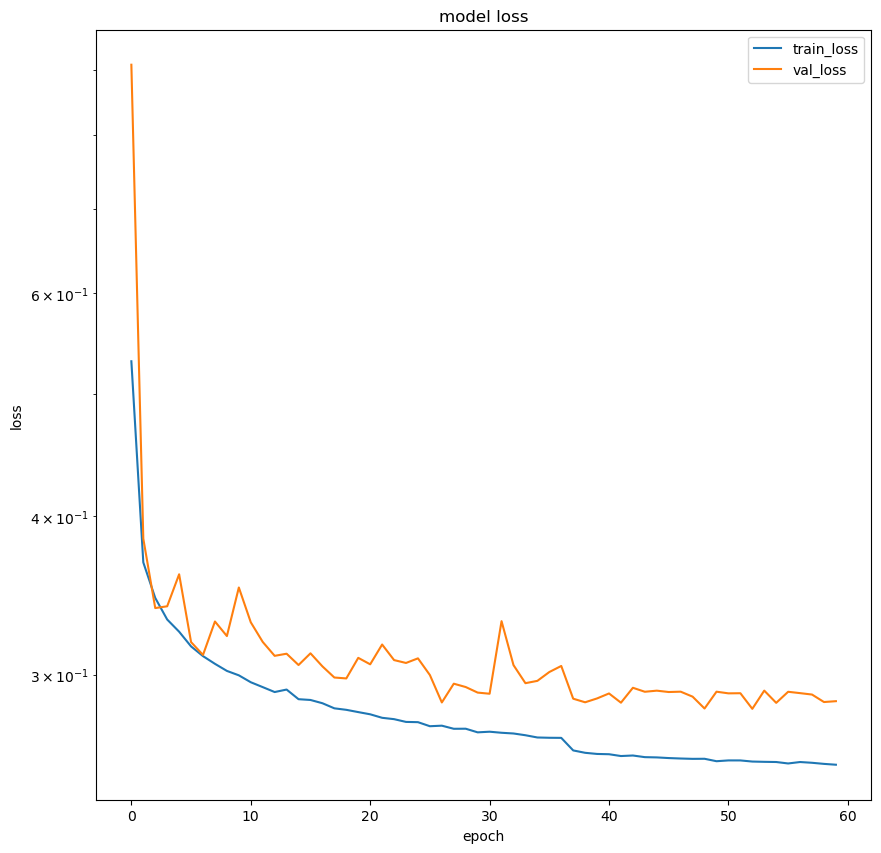

In [26]:
dir_path = "/albedo/work/user/ssunar/for_paper/unet_trained/Gulfstream_new"
plt.figure(figsize=(10, 10))
plt.semilogy(model.history.history['loss'])
plt.semilogy(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'], loc='upper right');
plt.savefig(dir_path + "/loss_graph.png", dpi = 300)

In [27]:
# Prediction on test data
test_inp = np.reshape(test_inp,(len(test_inp),img_size[0],img_size[1],1))
catagorical_test_preds = model.predict(test_inp)

32/32 [==============================] - 2s 34ms/step


In [28]:
mask = np.argmax(np.reshape(catagorical_test_preds[70],(1,img_size[1],img_size[0],3)), axis=-1)
mask = np.reshape(mask,(img_size[0],img_size[1]))

<Figure size 2000x1000 with 0 Axes>

<AxesSubplot:>

(-0.5, 255.5, 255.5, -0.5)

Text(0.5, 1.0, 'Result Segmentation')

<AxesSubplot:>

(-0.5, 255.5, 255.5, -0.5)

Text(0.5, 1.0, 'Groundtruth Segmentation')

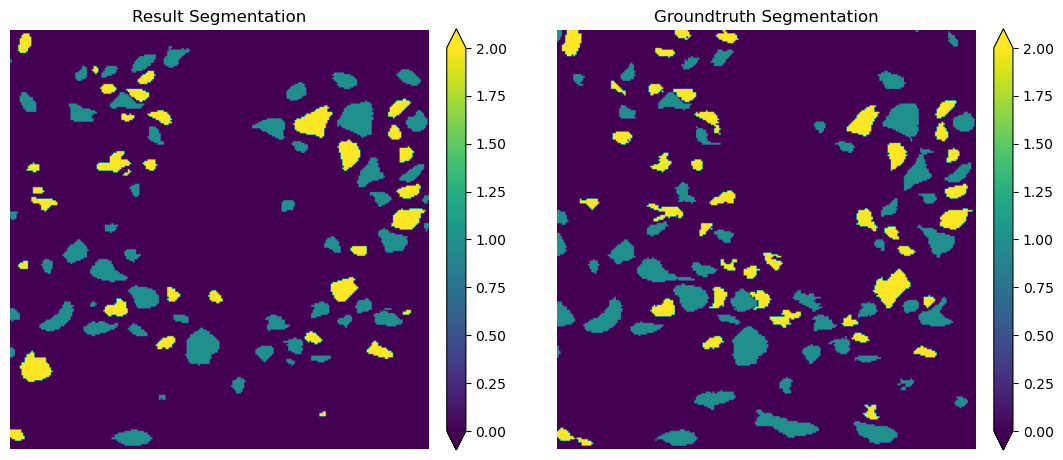

In [29]:
#seeing the prediction of one image of the validation set
%matplotlib inline

plt.figure(figsize=(20, 10))

plt.subplot(131)
plt.imshow(mask.T, cmap='viridis')
plt.colorbar(extend='both', fraction=0.042, pad=0.04)
plt.axis('off')
plt.title('Result Segmentation');
plt.savefig(dir_path + "/prediction.png", dpi = 300)

plt.subplot(132)
plt.imshow(test_seg[70].T, cmap='viridis')
plt.colorbar(extend='both', fraction=0.042, pad=0.04)
plt.axis('off')
plt.title('Groundtruth Segmentation');
plt.savefig(dir_path + "/groundtruth.png", dpi = 300)